In [1]:
import os
import sys
import glob

import numpy as np
from cora.util import units

from draco.util import tools
from fitstack import containers

In [2]:
import getdist
from getdist import plots, MCSamples

Matplotlib created a temporary cache directory at /tmp/matplotlib-hlcji1cs because the default path (/home/h/halpern/arnab92/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib inline

In [4]:
from draco.core.containers import FrequencyStack, FrequencyStackByPol, MockFrequencyStack, FormedBeam

In [5]:
import h5py
import getdist
from getdist import plots, MCSamples, chains, mcsamples
from cora.signal.lssmodels import bias
from cora.signal.lssmodels import omega_HI
from cora.signal import corr21cm
from cora.signal import lssmodels
from cora.util import cosmology

In [6]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  # or 'stix'
plt.rcParams.update({
    'font.size': 24,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# Using Richard's chaintools

In [7]:
from fitstack.chaintools import (  
    calc_fmu2_single,
    calc_fmu2,
    add_derived,
    apply_limits,
    hpd_chain,
    create_unified_config,
    scale_params,
    hpd_chain,
    combine_data
)
import pickle

# First load the chains. Note I have already ran cahintool.gdchain and save it in a pickly file

In [8]:
chain_path = "/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/chains/"
# chain_path_fixed = "/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/NL_fixed/chains/"

In [9]:
chain_path

'/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/chains/'

In [10]:
alphaFoG_power=-1.0
alphaFoG_min=0.1
alphaFoG_max=10.0
nsample=500000
nwalker=32

In [11]:
chain_path + f"chain_autops_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.gdchain"

'/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/chains/chain_autops_pow-1.0_FoGmin0.1_FoGmax10.0.gdchain'

In [12]:
with open(chain_path + f"chain_autops_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.gdchain", "rb") as fh:
    print(fh)
    chain_all = pickle.load(fh)
    chain_all.label = "All parameters"
    chain_all.tracer = "bandb"

<_io.BufferedReader name='/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/chains/chain_autops_pow-1.0_FoGmin0.1_FoGmax10.0.gdchain'>


# Scale the parameters actually fit to their values at the effective redshift.

In [13]:
# First load the dict containing all the relevant param values 
config = create_unified_config()

In [14]:
config

{'QSO': {'z_eff': 1.2034,
  'z_range': [1.0038, 1.365],
  'type': 'cross',
  'bias_key': 'eboss_qso',
  'b_HI': 1.5782310960156978,
  'omega_HI': 0.000642563420124033,
  'f': 0.9015817540176252,
  'b_g': 1.92122457368},
 'LRG': {'z_eff': 0.8372,
  'z_range': [0.8065, 0.8728],
  'type': 'cross',
  'bias_key': 'eboss_lrg',
  'b_HI': 1.410682907405958,
  'omega_HI': 0.000576174260879225,
  'f': 0.8450640065556718,
  'b_g': 2.4319062430400002},
 'ELG': {'z_eff': 0.9576,
  'z_range': [0.8253, 1.0264],
  'type': 'cross',
  'bias_key': 'eboss_elg',
  'b_HI': 1.469278654771197,
  'omega_HI': 0.0005985416343037188,
  'f': 0.8671616829717421,
  'b_g': 1.57532},
 'QSOb0': {'z_eff': 0.9714,
  'z_range': [0.8501, 1.0073],
  'type': 'cross',
  'bias_key': 'eboss_qso',
  'b_HI': 1.475745886048952,
  'omega_HI': 0.0006010697096585794,
  'f': 0.8694469155412741,
  'b_g': 1.65145627288},
 'QSOb1': {'z_eff': 1.117,
  'z_range': [1.0651, 1.1631],
  'type': 'cross',
  'bias_key': 'eboss_qso',
  'b_HI': 1.5

In [15]:
# Scale the chains
scale_params(chain_all,  config=config, identifier= "bandb")

In [16]:
params = chain_all.getParamNames().list()
print(params)

['omega', 'b_HI', 'NL', 'FoGh', 'omega_scaled', 'b_HI_scaled']


# Calculate the fmu2 from the chain (Omega_HI * b_HI) - Omega_HI plane

In [17]:
fm2 = calc_fmu2(chain_all,config,identifier="bandb", fscale=False)
print(f"{fm2=:.3f}")

fm2=0.782


In [18]:
fmu2 = calc_fmu2_single(
    [chain_all],config,identifier="bandb", fscale=False)


print(f"{fmu2=:.3f}")

fmu2=0.782


In [19]:
# Add a set of useful derived parameters
# Note: The fm2 param is 0.64 as estimated from stacking with fixed NL parameter for this data
# So, I am using that instead of fmu2 estimated from this chain

add_derived(chain_all, fmu2 = 0.64, cross_corr=False)

In [20]:
# Apply cutoff to a set of parameters.
apply_limits(
    chain_all,
    omega_scaled=(0, 5),
    b_HI_scaled=(0, 10),
    FoGh=(0, 5),
    copy=False,
)


In [21]:
orig_params = [
    "omega_scaled",
    "b_HI_scaled",
    "omega_b_HI",
    "omegabfm2",
    "NL",
    "FoGh",   
]

original_param_limits = {
    "omegabfm2": [0, 10],
    "omega_scaled": [0, 5],
    "b_HI_scaled": [0, 5],
    "omega_b_HI": [0, 4],
    "NL" : [0,5],
    "FoGh": [0,5],
}

In [22]:
save_path = "/scratch/h/halpern/arnab92/data/rev12/bandb/powerspectrums/data/fit_mcmc/plots/"

In [23]:
save = False

In [24]:
z_eff = config["bandb"]["z_eff"]
z_eff

1.159286

<Figure size 1000x1000 with 0 Axes>

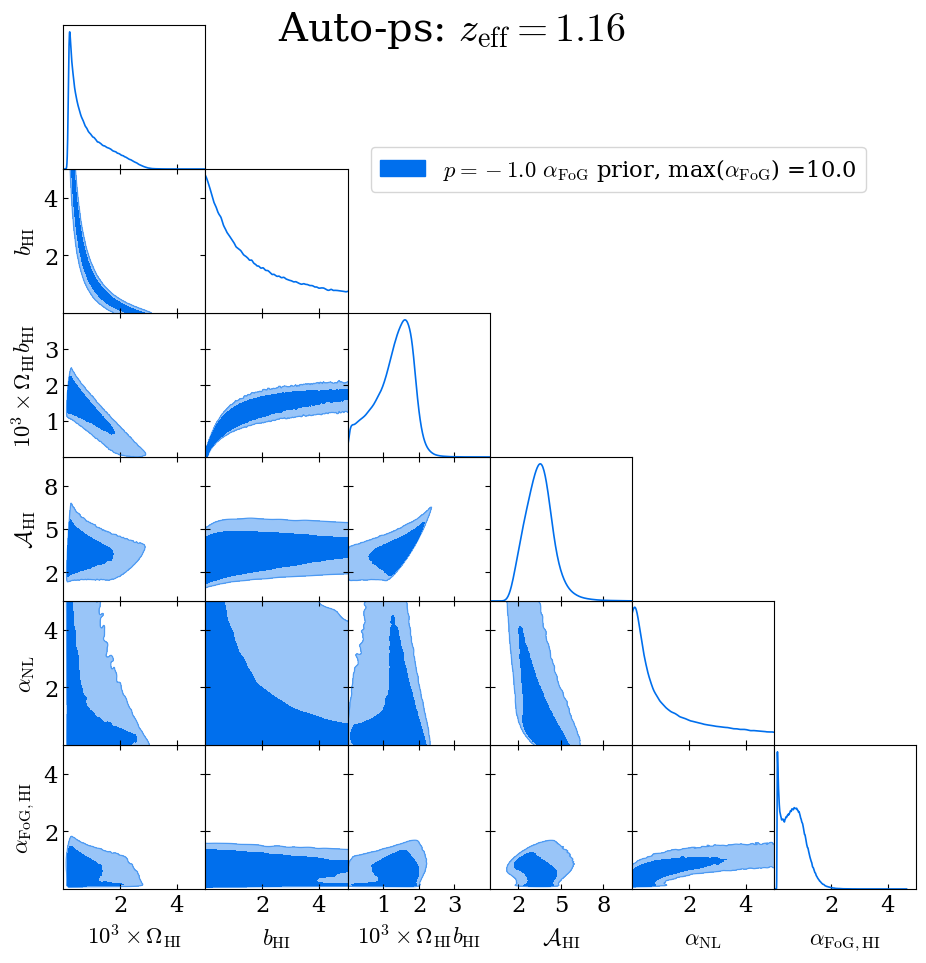

In [25]:
# Create plotter with larger size and better settings
g = plots.get_single_plotter(
    width_inch=10,           # Larger width for better readability
    scaling=True,
    ratio=1                  # Square aspect ratio
)

# Set additional GetDist-specific settings for publication quality
g.settings.axes_fontsize = 20        # Axis label font size
g.settings.lab_fontsize = 20         # Parameter label font size  
g.settings.legend_fontsize = 20      # Legend font size
#g.settings.colorbar_label_fontsize = 14
g.settings.title_limit_fontsize = 20

# Optional: Customize line widths and contour properties
g.settings.linewidth = 2.5           # Contour line width
g.settings.linewidth_contour = 2.0   # Filled contour edge width
g.settings.alpha_filled_add = 0.85   # Filled contour transparency

label = fr"$p={alphaFoG_power}$" + r" $\alpha_{\rm FoG}$ prior, max($\alpha_{\rm FoG}$) =" + fr"{alphaFoG_max}"
g.triangle_plot(
        [chain_all],
        orig_params,
        filled=True,
        #legend_loc="upper right",
        legend_labels=[label],  
        legend_loc=(0.4, 0.8),
        param_limits=original_param_limits,
        #line_args={'lw': 2.5},          # Line width for contours
        filled_compare=True,             # Better filled contours
        diag1d_kwargs={'normalized': True, 'lw': 2.5}  # 1D marginalized plots
    )
plt.suptitle(fr"Auto-ps: $z_\mathrm{{eff}} = {z_eff:.2f}$", va="top")
if save:
    g.export(save_path+f"origparams_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.pdf")
    g.export(save_path+f"origparams_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.png")

In [26]:
# reduced params plot 
new_params = [
    "omega_scaled",
    "b_HI_scaled",
    "omega_b_HI",
    "omegabfm2",
]

param_limits = {
    "omegabfm2": [0, 10],
    "omega_scaled": [0, 5],
    "b_HI_scaled": [0, 5],
    "omega_b_HI": [0, 4],
}


In [27]:
chain_all.label = (
        fr"All parameters - $\chi^2_\mathrm{{min}} = {2 * chain_all.loglikes.min():.1f}$"
    )


In [28]:
chain_all.label

'All parameters - $\\chi^2_\\mathrm{min} = 10.9$'

/tmp/ipykernel_255440/2662632556.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x1000 with 0 Axes>

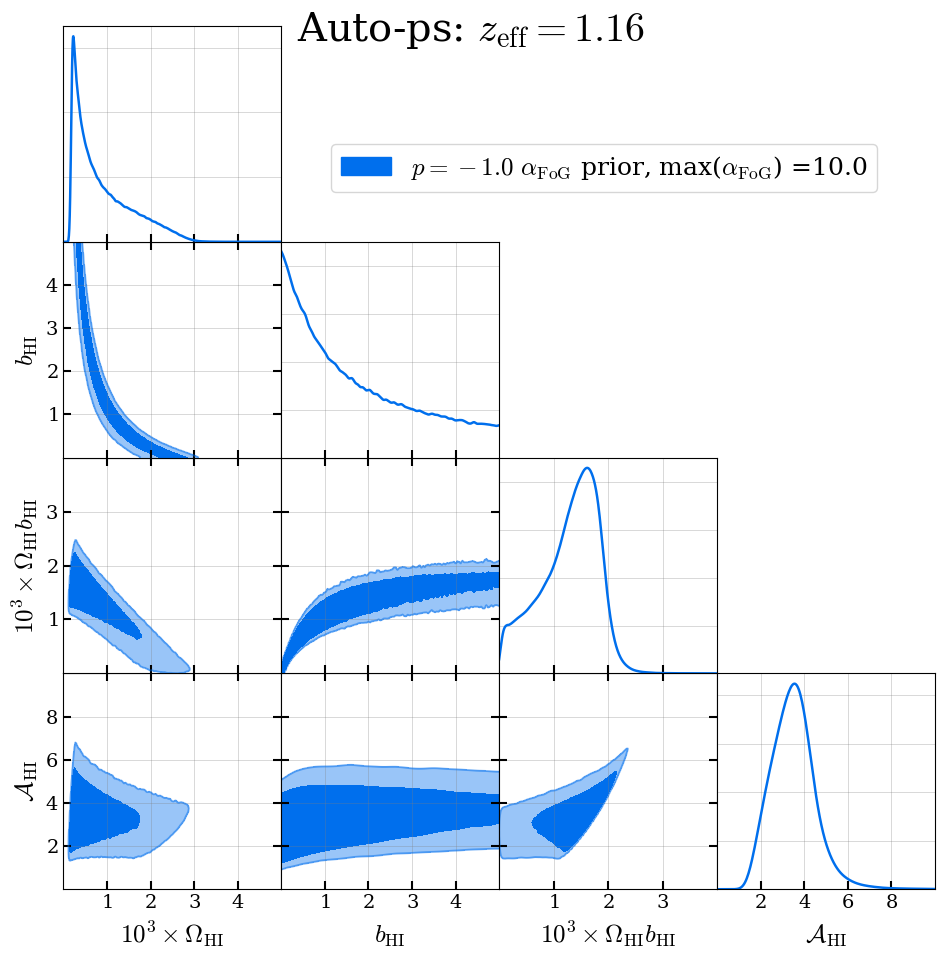

In [29]:
# Create plotter with larger size and better settings
g = plots.get_single_plotter(
    width_inch=10,           # Larger width for better readability
    scaling=True,
    ratio=1                  # Square aspect ratio
)

# Set additional GetDist-specific settings for publication quality
g.settings.axes_fontsize = 20        # Axis label font size
g.settings.lab_fontsize = 20         # Parameter label font size  
g.settings.legend_fontsize = 20      # Legend font size
#g.settings.colorbar_label_fontsize = 14
g.settings.title_limit_fontsize = 20

# Optional: Customize line widths and contour properties
g.settings.linewidth = 2.5           # Contour line width
g.settings.linewidth_contour = 2.0   # Filled contour edge width
g.settings.alpha_filled_add = 0.85   # Filled contour transparency

label = fr"$p={alphaFoG_power}$" + r" $\alpha_{\rm FoG}$ prior, max($\alpha_{\rm FoG}$) =" + fr"{alphaFoG_max}"
g.triangle_plot(
        [chain_all],
        new_params,
        filled=True,
        legend_labels=[label], 
        legend_loc=(0.35, 0.8),
        param_limits=param_limits,
        filled_compare=True,             # Better filled contours
        diag1d_kwargs={'normalized': True, 'lw': 2.5}  # 1D marginalized plots
            )
plt.suptitle(fr"Auto-ps: $z_\mathrm{{eff}} = {z_eff:.2f}$", va="top")

# Optional: Further customize the plot after creation
axes = g.subplots
for i in range(len(new_params)):
    for j in range(i+1):
        ax = axes[i, j]
        
        # Make tick labels larger and clearer
        ax.tick_params(labelsize=14, width=1.5, length=6)
        
        # Add grid for better readability (optional)
        ax.grid(True,color='gray', alpha=0.3, linewidth=0.7)
        
        # Ensure labels are not cut off
        ax.margins(0.02)

# Adjust layout to prevent label cutoff
plt.tight_layout()

if save:
    g.export(save_path+f"reducedparams_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.pdf")
    g.export(save_path+f"reducedparams_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.png")



In [30]:
# Estimate the A_HI(auto) from the chain
mode_all, err_all = hpd_chain(chain_all,"omegabfm2")
print(mode_all, err_all)

3.552011640343898 [1.0994722525103802, 0.7969145282179078]


In [31]:
np.sqrt(mode_all)

1.8846781264565835

# Omega_HI constraint

# Add a prior on the value of b_HI of 20% fractional

In [32]:
llprior = 0.5 * ((chain_all["b_HI"] - 1.0) / 0.2) ** 2

In [33]:
re_weight = True
if re_weight:
    chain_all.reweightAddingLogLikes(llprior)

In [34]:
z_range = config["bandb"]["z_range"]
z_range

[1.0006, 1.335]

In [35]:
za_eff = np.array(z_eff)
zerr_eff = np.abs(np.array([z_range]).T - za_eff)

In [36]:
za_eff, zerr_eff

(array(1.159286),
 array([[0.158686],
        [0.175714]]))

In [37]:
# param values of Omega_HI from the chain
ms_all, errsa_all = hpd_chain(chain_all, "omega_scaled")

In [38]:
ms_all, errsa_all

(0.8341956818686768, [0.1541242185527839, 0.17813662881534975])

In [39]:
# Load other data
import yaml
with open("otherdata.yaml", "r") as fh:
    data = yaml.safe_load(fh)

In [40]:
# Process GBT numbers
# WiggleZ, ELG, LRG order
om_b_r = np.array([0.70, 0.55, 0.45])
errs = np.array([0.12, 0.11, 0.10])

r = np.array([0.9, 0.7, 0.6])
b_HI = 1 + lssmodels.bias["HI"](0.78)

om_GBT = om_b_r / b_HI / r

# Calculate errors for GBT, and add in a 20% uncertainty on the bias
err_GBT = om_GBT * ((errs / om_b_r)**2 + 0.2**2)**0.5
z_GBT = np.array([0.74, 0.78, 0.82])


types = [
    ("HI_direct", "HI direct", "o"),
    ("HI_stack", "HI stacking", "v"),
    ("HI_im", "HI intensity mapping", ">"),
    ("DLA", "Damped Lyman alpha", "s"),
]

c = cosmology.Cosmology()

In [41]:
markers = ["o", "v", "^", "<", ">", "8", "s", "p", "P", "*", "h", "X"]

In [42]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  # or 'stix'
plt.rcParams.update({
    'font.size': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24
})

In [43]:
save

False

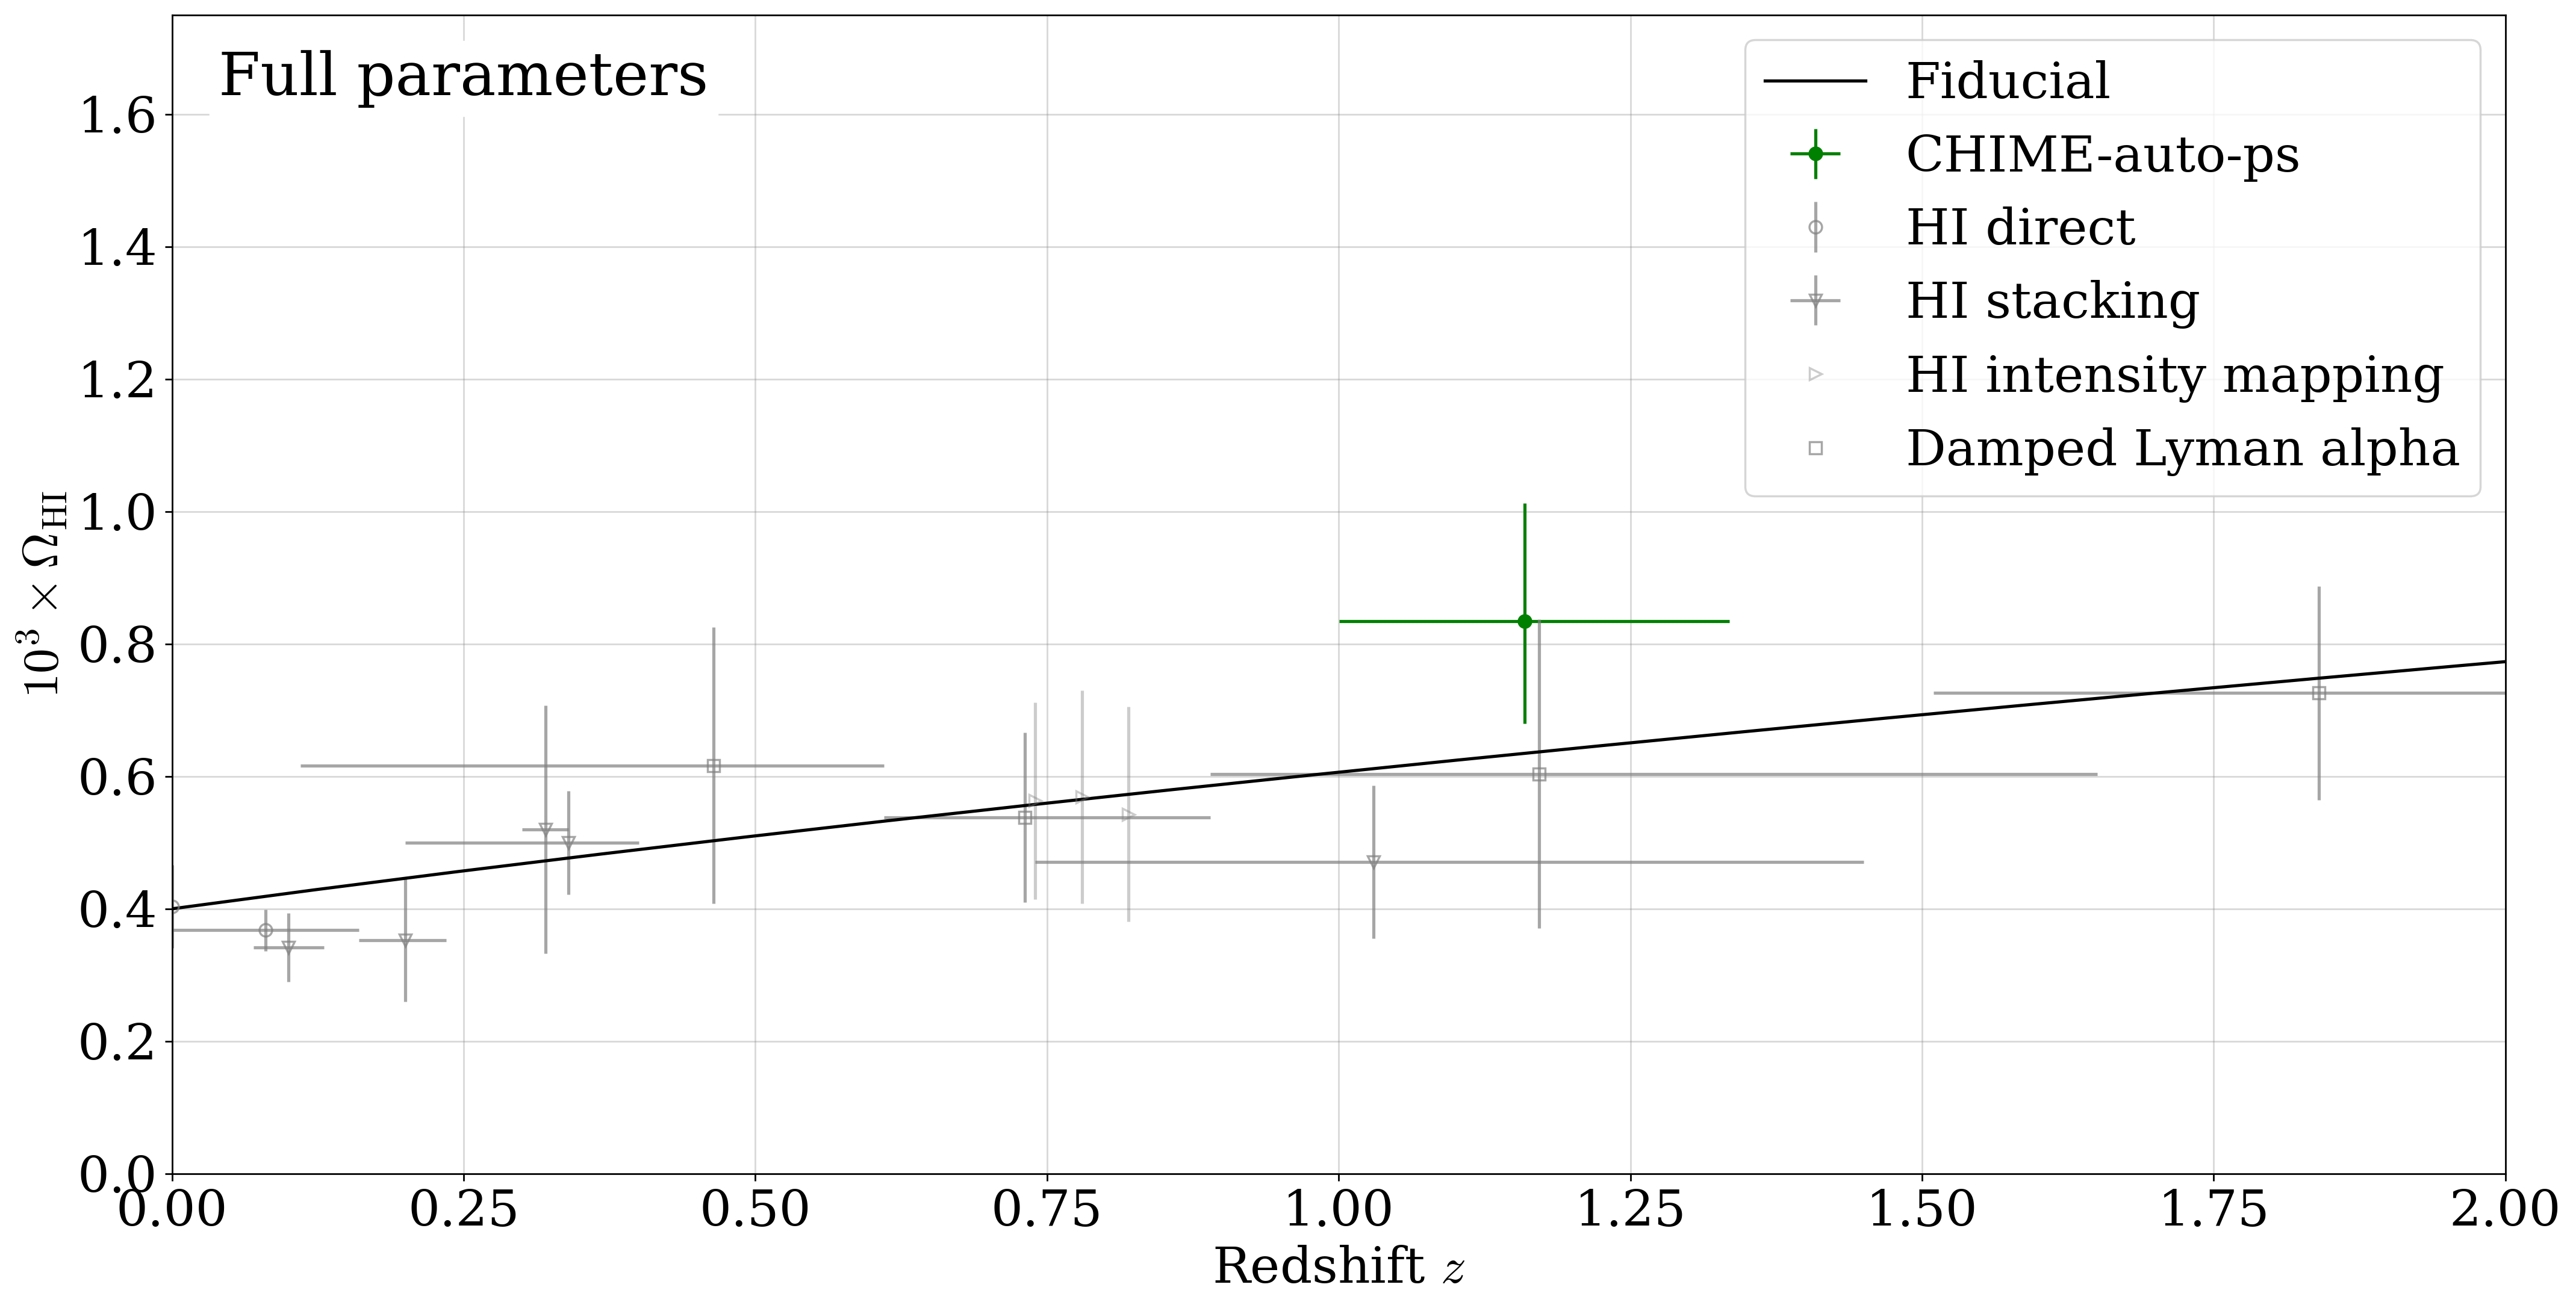

In [44]:
fig = plt.figure(num=1, figsize=(20, 10), dpi=250, linewidth=1.5)

# Create axes (assuming you want a single subplot, modify if you need multiple)
ax = plt.gca()

# plot the CHIME data
yerr = np.array([[errsa_all[0]], [errsa_all[1]]])
plt.errorbar(
    za_eff,
    ms_all,
    xerr=zerr_eff,
    yerr=yerr,
    marker='o',
    color='green',
    ls="",
    label=f"CHIME-auto-ps",
)

# Now plot all other surveys 
for type_, label, marker in types:
    z = []
    om = []
    z_err = []
    om_err = []
    labelled = False
    if type_ == "HI_im":
        # Add in the GBT points by hand rather than trying to insert into the OmegaHI
        # data file
        plt.errorbar(
            z_GBT,
            om_GBT,
            xerr=None,
            yerr=err_GBT,
            label=label,
            marker=marker,
            markersize=6,
            ls="",
            color="gray",
            alpha=0.4,
            fillstyle="none",
        )
        continue
    for name, dset in data.items():
        if dset["type"] != type_:
            continue
        if type_ == "HI_stack" and name in ["delhaize2013", "chen2021"]:
            continue
        ds = combine_data(dset, cosmo=c)
        z = ds["z"]
        z_err = ds["zerr"]
        om = 1e3 * ds["omega_HI"]
        om_err = 1e3 * ds["omega_HI_err"]
        l = None if labelled else label
        labelled = True
        
        plt.errorbar(
            z,
            om,
            xerr=z_err,
            yerr=om_err,
            label=l,
            marker=marker,
            markersize=6,
            ls="",
            color="gray",
            alpha=0.7,
            fillstyle="none",
        )

za = np.linspace(0, 6)
omHI = lssmodels.omega_HI.evaluate(za)
plt.plot(za, 1e3 * omHI, "k-", label="Fiducial")

plt.xlim(0, 2)
plt.ylim(0, 1.75)
plt.xlabel("Redshift $z$")
plt.ylabel(r"$10^3 \times \Omega_\mathrm{HI}$")
plt.grid(color='gray', alpha=0.3)

## Fix up the legend
# get handles
handles, labels = ax.get_legend_handles_labels()
# remove the errorbars
handles = [h[0] if ii > 3 else h for ii, h in enumerate(handles)]
# use them in the legend
ax.legend(handles, labels, loc="upper right", ncol=1, numpoints=1)

# Add text labels (modify as needed for your specific case)
ax.text(
    0.02,
    1.0 - 0.03,
    "Full parameters",  # Change this label as needed
    transform=ax.transAxes,
    fontsize="large",
    bbox=dict(fc="w", ec="w"),
    verticalalignment="top",
)

if save: 
   plt.savefig(save_path+f"omegaHI_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.pdf")
   plt.savefig(save_path+f"omegaHI_pow{alphaFoG_power}_FoGmin{alphaFoG_min}_FoGmax{alphaFoG_max}.png")